In [2]:
import os
import zipfile
import urllib.request
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# A

In [3]:
url = "https://www.bgc-jena.mpg.de/wetter/mpi_saale_2021b.zip"
zip_path = "mpi_saale_2021b.zip"
extract_dir = "jena_data"

if not os.path.exists(zip_path):
    print("Pobieranie danych pogodowych...")
    urllib.request.urlretrieve(url, zip_path)
    print("Pobieranie zakończone.")

if not os.path.exists(extract_dir):
    print("Rozpakowywanie...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

csv_file = [f for f in os.listdir(extract_dir) if f.endswith('.csv')][0]
csv_path = os.path.join(extract_dir, csv_file)

print(f"Wczytywanie pliku: {csv_path}")
df = pd.read_csv(csv_path)

Pobieranie danych pogodowych...
Pobieranie zakończone.
Rozpakowywanie...
Wczytywanie pliku: jena_data/mpi_saale_2021b.csv


In [4]:
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
df = df.dropna(subset=['Date Time']).sort_values('Date Time').reset_index(drop=True)

target_col = 'T (degC)'
data = df[[target_col]].values

print(f"Liczba wszystkich odczytów: {len(data)}")

Liczba wszystkich odczytów: 26496


In [ ]:
n = len(data) 
train_end = int(n * 0.7)
val_end = int(n * 0.8)

# chornolgoiczny split train 70, val 10, test 20
train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

In [ ]:
# FORECASTIGN HORIZON
SEQ_LENGTH = 30 # na postawie 30 dni będziemy przewidywać jeden dzien do przodu

def create_sequences(dataset, seq_length):
    X, y = [], []
    for i in range(len(dataset) - seq_length):
        X.append(dataset[i : i + seq_length])
        y.append(dataset[i + seq_length])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)
X_val, y_val = create_sequences(val_scaled, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQ_LENGTH)

print(f"Kształt X_train: {X_train.shape}")
print(f"Kształt y_train: {y_train.shape}")

Kształt X_train: (18517, 30, 1)
Kształt y_train: (18517, 1)


# B i C

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time

In [13]:
def select_device():
    if torch.cuda.is_available():
        return "cuda"
    elif torch.mps.is_available():
        return "mps"
    return "cpu"

device = torch.device(select_device())
print(f"Używane urządzenie: {device}")

Używane urządzenie: mps


In [14]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)

X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

batch_size = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # WAŻNE: shuffle=False dla szeregów czasowych!

In [21]:
def train_model(model, train_loader, X_val_t, y_val_t, criterion, optimizer, num_epochs=20, patience=5, model_save_path='best_model.pth', device='cpu'):
    print(f"\nRozpoczynamy trening modelu {model.__class__.__name__} na device: {device}...")
    start_time = time.time()
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # TRENING
        model.train()
        batch_losses = []
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
            
        avg_train_loss = np.mean(batch_losses)
        train_losses.append(avg_train_loss)
        
        # WALIDACJA
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            val_losses.append(val_loss)
            
        print(f"Epoka [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Zapisujemy wagi najlepszego modelu
            torch.save(model.state_dict(), model_save_path)
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Brak poprawy na walidacji przez {patience} epok. Prerywam trening!")
            break

    # Ładujemy z powrotem najlepsze wagi do modelu
    model.load_state_dict(torch.load(model_save_path))
    
    end_time = time.time()
    print(f"Trening zakończony w {end_time - start_time:.2f} s. Najlepszy Val Loss: {best_val_loss:.4f}")
    
    return train_losses, val_losses

In [22]:
class WeatherLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.3):
        super(WeatherLSTM, self).__init__()
        self.hidden_size = hidden_size
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout)
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x ma wymiary: (batch_size, seq_length, input_size)
        
        # Przejście przez LSTM. 
        # Zwraca wszystkie wyjścia 'out' oraz stan ukryty 'hn' i stan komórki 'cn'
        out, (hn, cn) = self.lstm(x)
        
        # Interesuje nas tylko wyjście z ostatniego kroku czasowego: out[:, -1, :]
        last_out = out[:, -1, :]
        last_out = self.dropout(last_out)
        
        # Przejście przez warstwę liniową
        pred = self.fc(last_out)
        return pred

In [24]:
model_lstm = WeatherLSTM().to(device)
criterion_lstm = nn.MSELoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.001)

train_loss_lstm, val_loss_lstm = train_model(
    model=model_lstm, 
    train_loader=train_loader, 
    X_val_t=X_val_t, 
    y_val_t=y_val_t, 
    criterion=criterion_lstm, 
    optimizer=optimizer_lstm, 
    model_save_path='best_lstm.pth',
    device=device
)


Rozpoczynamy trening modelu WeatherLSTM na device: mps...
Epoka [1/20] | Train Loss: 0.1122 | Val Loss: 0.0124
Epoka [2/20] | Train Loss: 0.0228 | Val Loss: 0.0090
Epoka [3/20] | Train Loss: 0.0190 | Val Loss: 0.0067
Epoka [4/20] | Train Loss: 0.0167 | Val Loss: 0.0042
Epoka [5/20] | Train Loss: 0.0153 | Val Loss: 0.0038
Epoka [6/20] | Train Loss: 0.0145 | Val Loss: 0.0039
Epoka [7/20] | Train Loss: 0.0140 | Val Loss: 0.0037
Epoka [8/20] | Train Loss: 0.0130 | Val Loss: 0.0025
Epoka [9/20] | Train Loss: 0.0121 | Val Loss: 0.0025
Epoka [10/20] | Train Loss: 0.0120 | Val Loss: 0.0023
Epoka [11/20] | Train Loss: 0.0111 | Val Loss: 0.0020
Epoka [12/20] | Train Loss: 0.0109 | Val Loss: 0.0017
Epoka [13/20] | Train Loss: 0.0108 | Val Loss: 0.0038
Epoka [14/20] | Train Loss: 0.0103 | Val Loss: 0.0018
Epoka [15/20] | Train Loss: 0.0105 | Val Loss: 0.0018
Epoka [16/20] | Train Loss: 0.0101 | Val Loss: 0.0012
Epoka [17/20] | Train Loss: 0.0100 | Val Loss: 0.0013
Epoka [18/20] | Train Loss: 0.00

/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_11286/1753343358.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_

In [25]:
class WeatherGRU(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.3):
        super(WeatherGRU, self).__init__()
        self.hidden_size = hidden_size
        
        # Jedyna zmiana w architekturze: używamy nn.GRU zamiast nn.LSTM
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # W GRU otrzymujemy wyjścia 'out' i JEDEN stan ukryty 'hn' (nie ma stanu komórki 'cn')
        out, hn = self.gru(x)
        
        # Bierzemy wyjście z ostatniego kroku czasowego
        last_out = out[:, -1, :]
        last_out = self.dropout(last_out)
        
        # Przewidywanie
        pred = self.fc(last_out)
        return pred

In [26]:
model_gru = WeatherGRU().to(device)
criterion_gru = nn.MSELoss()
optimizer_gru = optim.Adam(model_gru.parameters(), lr=0.001)

train_loss_gru, val_loss_gru = train_model(
    model=model_gru, 
    train_loader=train_loader, 
    X_val_t=X_val_t, 
    y_val_t=y_val_t, 
    criterion=criterion_gru, 
    optimizer=optimizer_gru, 
    model_save_path='best_gru.pth',
    device=device
)


Rozpoczynamy trening modelu WeatherGRU na device: mps...
Epoka [1/20] | Train Loss: 0.1045 | Val Loss: 0.0081
Epoka [2/20] | Train Loss: 0.0181 | Val Loss: 0.0051
Epoka [3/20] | Train Loss: 0.0152 | Val Loss: 0.0043
Epoka [4/20] | Train Loss: 0.0137 | Val Loss: 0.0024
Epoka [5/20] | Train Loss: 0.0125 | Val Loss: 0.0019
Epoka [6/20] | Train Loss: 0.0124 | Val Loss: 0.0024
Epoka [7/20] | Train Loss: 0.0114 | Val Loss: 0.0019
Epoka [8/20] | Train Loss: 0.0111 | Val Loss: 0.0015
Epoka [9/20] | Train Loss: 0.0107 | Val Loss: 0.0034
Epoka [10/20] | Train Loss: 0.0103 | Val Loss: 0.0015
Epoka [11/20] | Train Loss: 0.0102 | Val Loss: 0.0012
Epoka [12/20] | Train Loss: 0.0100 | Val Loss: 0.0016
Epoka [13/20] | Train Loss: 0.0099 | Val Loss: 0.0013
Epoka [14/20] | Train Loss: 0.0094 | Val Loss: 0.0010
Epoka [15/20] | Train Loss: 0.0098 | Val Loss: 0.0019
Epoka [16/20] | Train Loss: 0.0097 | Val Loss: 0.0009
Epoka [17/20] | Train Loss: 0.0096 | Val Loss: 0.0016
Epoka [18/20] | Train Loss: 0.009

/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_11286/1753343358.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_

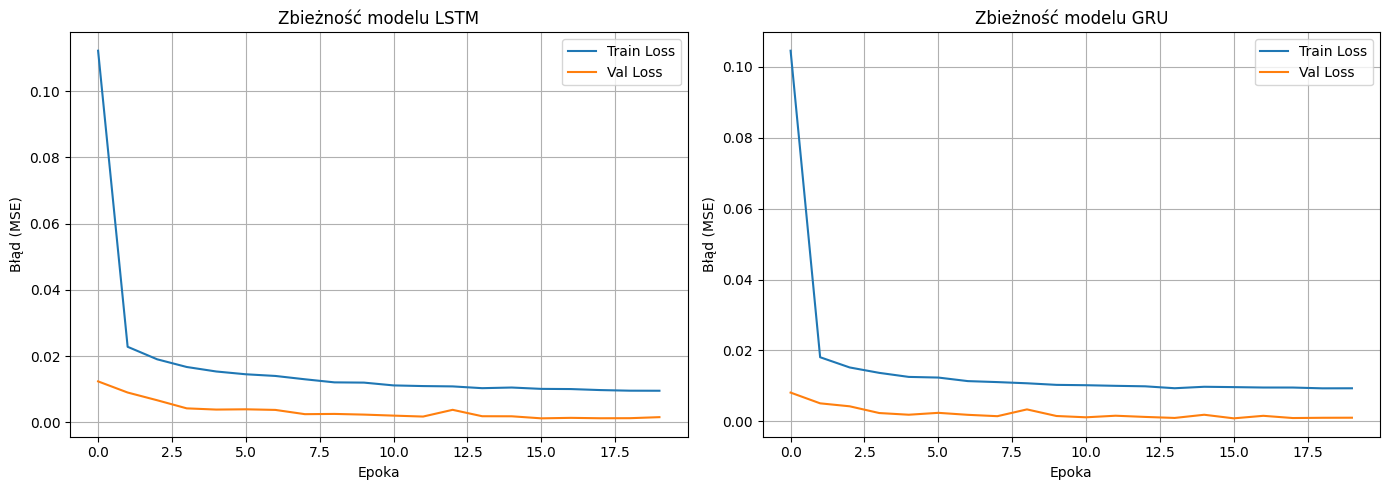

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres LSTM
axes[0].plot(train_loss_lstm, label='Train Loss')
axes[0].plot(val_loss_lstm, label='Val Loss')
axes[0].set_title('Zbieżność modelu LSTM')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Błąd (MSE)')
axes[0].legend()
axes[0].grid(True)

# Wykres GRU
axes[1].plot(train_loss_gru, label='Train Loss')
axes[1].plot(val_loss_gru, label='Val Loss')
axes[1].set_title('Zbieżność modelu GRU')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Błąd (MSE)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# D

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


# 1. Funkcja pomocnicza do ewaluacji modeli w PyTorch
def evaluate_model(model, X_tensor, y_tensor, scaler):
    model.eval()
    with torch.no_grad():
        # Predykcja modelu (w skali znormalizowanej)
        y_pred_scaled = model(X_tensor).cpu().numpy()
        y_true_scaled = y_tensor.cpu().numpy()
        
        # Odwracanie skalowania (żeby błąd był w realnych stopniach Celsjusza!)
        y_pred = scaler.inverse_transform(y_pred_scaled)
        y_true = scaler.inverse_transform(y_true_scaled)
        
        # Obliczanie metryk
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        
    return mae, rmse, y_pred, y_true

In [32]:
# Ewaluacja LSTM
mae_lstm, rmse_lstm, preds_lstm, true_values = evaluate_model(model_lstm, X_test_t, y_test_t, scaler)

# Ewaluacja GRU
mae_gru, rmse_gru, preds_gru, _ = evaluate_model(model_gru, X_test_t, y_test_t, scaler)


# Obliczanie Naiwnego Baseline'u (Naive Forecast)
# Predykcja naiwna = ostatnia wartość z sekwencji wejściowej (X)
# X_test ma wymiary (liczba_próbek, 30_kroków, 1_cecha). Bierzemy krok -1.
naive_preds_scaled = X_test[:, -1, 0].reshape(-1, 1)
naive_preds = scaler.inverse_transform(naive_preds_scaled)

mae_naive = mean_absolute_error(true_values, naive_preds)
rmse_naive = np.sqrt(mean_squared_error(true_values, naive_preds))

In [31]:
print("\n" + "="*40)
print(" WYNIKI EWALUACJI NA ZBIORZE TESTOWYM ")
print("="*40)
print(f"1. NAIVE BASELINE (Dziś == Jutro):")
print(f"   MAE:  {mae_naive:.4f} °C")
print(f"   RMSE: {rmse_naive:.4f} °C")
print("-" * 40)
print(f"2. MODEL LSTM:")
print(f"   MAE:  {mae_lstm:.4f} °C")
print(f"   RMSE: {rmse_lstm:.4f} °C")
print("-" * 40)
print(f"3. MODEL GRU:")
print(f"   MAE:  {mae_gru:.4f} °C")
print(f"   RMSE: {rmse_gru:.4f} °C")
print("="*40)


 WYNIKI EWALUACJI NA ZBIORZE TESTOWYM 
1. NAIVE BASELINE (Dziś == Jutro):
   MAE:  0.1262 °C
   RMSE: 0.2088 °C
----------------------------------------
2. MODEL LSTM:
   MAE:  0.1543 °C
   RMSE: 0.2434 °C
----------------------------------------
3. MODEL GRU:
   MAE:  0.1303 °C
   RMSE: 0.2072 °C


# E

In [33]:
print("\nEKSPERYMENT 1: LSTM (num_layers=2, hidden_size=128)")

# Inicjalizacja modelu z nowymi parametrami
model_lstm_deep = WeatherLSTM(hidden_size=128, num_layers=2).to(device)
criterion_lstm_deep = nn.MSELoss()
optimizer_lstm_deep = optim.Adam(model_lstm_deep.parameters(), lr=0.001)

# Trening głębokiego LSTM
train_loss_lstm_deep, val_loss_lstm_deep = train_model(
    model=model_lstm_deep, 
    train_loader=train_loader, 
    X_val_t=X_val_t, 
    y_val_t=y_val_t, 
    criterion=criterion_lstm_deep, 
    optimizer=optimizer_lstm_deep, 
    model_save_path='best_lstm_deep.pth',
    device=device
)

# Ewaluacja głębokiego LSTM na zbiorze testowym
mae_lstm_deep, rmse_lstm_deep, preds_lstm_deep, _ = evaluate_model(model_lstm_deep, X_test_t, y_test_t, scaler)


EKSPERYMENTY Z HIPERPARAMETRAMI 

EKSPERYMENT 1: LSTM (num_layers=2, hidden_size=128)

Rozpoczynamy trening modelu WeatherLSTM na device: mps...
Epoka [1/20] | Train Loss: 0.0640 | Val Loss: 0.8680
Epoka [2/20] | Train Loss: 0.0191 | Val Loss: 0.8636
Epoka [3/20] | Train Loss: 0.0190 | Val Loss: 0.8484
Epoka [4/20] | Train Loss: 0.0174 | Val Loss: 0.8408
Epoka [5/20] | Train Loss: 0.0185 | Val Loss: 0.7436
Epoka [6/20] | Train Loss: 0.0179 | Val Loss: 0.7070
Epoka [7/20] | Train Loss: 0.0177 | Val Loss: 0.7275
Epoka [8/20] | Train Loss: 0.0182 | Val Loss: 0.6807
Epoka [9/20] | Train Loss: 0.0177 | Val Loss: 0.6377
Epoka [10/20] | Train Loss: 0.0185 | Val Loss: 0.6483
Epoka [11/20] | Train Loss: 0.0181 | Val Loss: 0.6189
Epoka [12/20] | Train Loss: 0.0188 | Val Loss: 0.5309
Epoka [13/20] | Train Loss: 0.0174 | Val Loss: 0.6182
Epoka [14/20] | Train Loss: 0.0180 | Val Loss: 0.5958
Epoka [15/20] | Train Loss: 0.0198 | Val Loss: 0.6279
Epoka [16/20] | Train Loss: 0.0175 | Val Loss: 0.5757

/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_11286/1753343358.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_

In [34]:
print("\nEKSPERYMENT 2: GRU (Learning Rate = 0.01)")

# Inicjalizacja standardowego GRU
model_gru_fast = WeatherGRU().to(device)
criterion_gru_fast = nn.MSELoss()

# ZMIANA HIPERPARAMETRU: Zwiększony Learning Rate
optimizer_gru_fast = optim.Adam(model_gru_fast.parameters(), lr=0.01)

# Trening GRU z nowym LR
train_loss_gru_fast, val_loss_gru_fast = train_model(
    model=model_gru_fast, 
    train_loader=train_loader, 
    X_val_t=X_val_t, 
    y_val_t=y_val_t, 
    criterion=criterion_gru_fast, 
    optimizer=optimizer_gru_fast, 
    model_save_path='best_gru_fast.pth',
    device=device
)

# Ewaluacja szybkiego GRU na zbiorze testowym
mae_gru_fast, rmse_gru_fast, preds_gru_fast, _ = evaluate_model(model_gru_fast, X_test_t, y_test_t, scaler)


EKSPERYMENT 2: GRU (Learning Rate = 0.01)

Rozpoczynamy trening modelu WeatherGRU na device: mps...
Epoka [1/20] | Train Loss: 0.0197 | Val Loss: 0.0024
Epoka [2/20] | Train Loss: 0.0127 | Val Loss: 0.0130
Epoka [3/20] | Train Loss: 0.0120 | Val Loss: 0.0015
Epoka [4/20] | Train Loss: 0.0122 | Val Loss: 0.0074
Epoka [5/20] | Train Loss: 0.0116 | Val Loss: 0.0010
Epoka [6/20] | Train Loss: 0.0118 | Val Loss: 0.0015
Epoka [7/20] | Train Loss: 0.0123 | Val Loss: 0.0110
Epoka [8/20] | Train Loss: 0.0119 | Val Loss: 0.0016
Epoka [9/20] | Train Loss: 0.0120 | Val Loss: 0.0016
Epoka [10/20] | Train Loss: 0.0127 | Val Loss: 0.0031
Brak poprawy na walidacji przez 5 epok. Prerywam trening!
Trening zakończony w 110.20 s. Najlepszy Val Loss: 0.0010


/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_11286/1753343358.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_

In [36]:
print("PODSUMOWANIE EKSPERYMENTÓW NA ZBIORZE TESTOWYM ")

print(f"1. LSTM BAZOWE (1 warstwa, 64 neurony):")
print(f"   MAE:  {mae_lstm:.4f} °C  | RMSE: {rmse_lstm:.4f} °C")
print(f"2. LSTM EKSPERYMENT (2 warstwy, 128 neuronów):")
print(f"   MAE:  {mae_lstm_deep:.4f} °C  | RMSE: {rmse_lstm_deep:.4f} °C")
print("-" * 50)
print(f"3. GRU BAZOWE (LR = 0.001):")
print(f"   MAE:  {mae_gru:.4f} °C  | RMSE: {rmse_gru:.4f} °C")
print(f"4. GRU EKSPERYMENT (LR = 0.01):")
print(f"   MAE:  {mae_gru_fast:.4f} °C  | RMSE: {rmse_gru_fast:.4f} °C")

PODSUMOWANIE EKSPERYMENTÓW NA ZBIORZE TESTOWYM 
1. LSTM BAZOWE (1 warstwa, 64 neurony):
   MAE:  0.1543 °C  | RMSE: 0.2434 °C
2. LSTM EKSPERYMENT (2 warstwy, 128 neuronów):
   MAE:  5.1575 °C  | RMSE: 5.5485 °C
--------------------------------------------------
3. GRU BAZOWE (LR = 0.001):
   MAE:  0.1303 °C  | RMSE: 0.2072 °C
4. GRU EKSPERYMENT (LR = 0.01):
   MAE:  0.1462 °C  | RMSE: 0.2078 °C


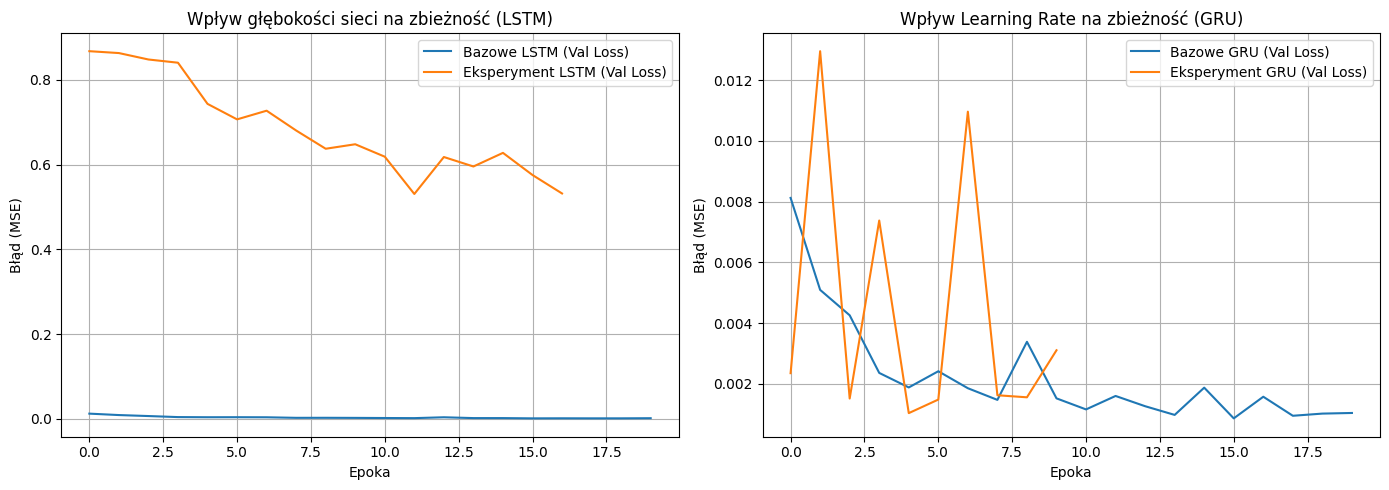

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Porównanie LSTM
axes[0].plot(val_loss_lstm, label='Bazowe LSTM (Val Loss)')
axes[0].plot(val_loss_lstm_deep, label='Eksperyment LSTM (Val Loss)')
axes[0].set_title('Wpływ głębokości sieci na zbieżność (LSTM)')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Błąd (MSE)')
axes[0].legend()
axes[0].grid(True)

# Porównanie GRU
axes[1].plot(val_loss_gru, label='Bazowe GRU (Val Loss)')
axes[1].plot(val_loss_gru_fast, label='Eksperyment GRU (Val Loss)')
axes[1].set_title('Wpływ Learning Rate na zbieżność (GRU)')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Błąd (MSE)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# F


Generowanie wykresów porównawczych na zbiorze testowym...


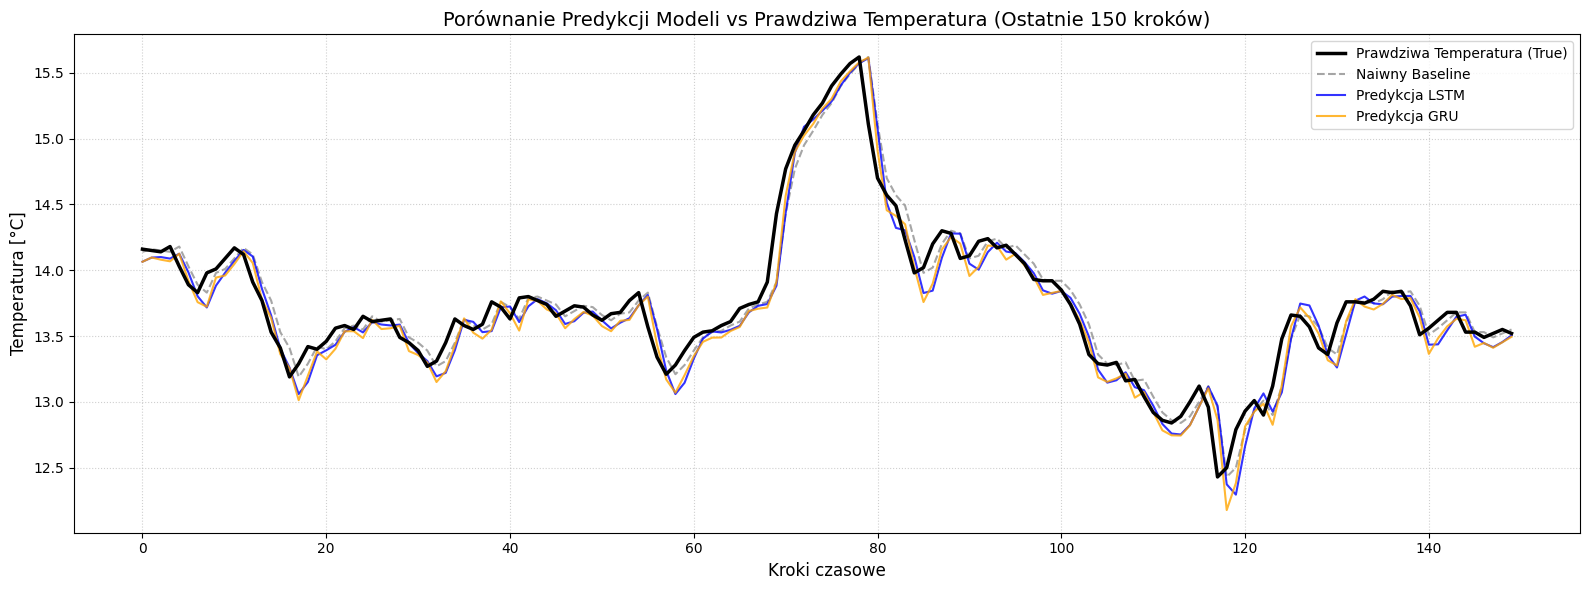

In [38]:
print("\nGenerowanie wykresów porównawczych na zbiorze testowym...")

# Wybieramy "wycinek" do narysowania, np. ostatnie 150 kroków czasowych ze zbioru testowego.
# Pokaże to szczegółowo, jak modele zachowują się na kilkudniowym wycinku pogody.
PLOT_WINDOW = 150

# Pobieramy końcówkę tablic
true_subset = true_values[-PLOT_WINDOW:]
lstm_subset = preds_lstm[-PLOT_WINDOW:]
gru_subset = preds_gru[-PLOT_WINDOW:]
naive_subset = naive_preds[-PLOT_WINDOW:]

# Tworzymy oś czasu dla wykresu (od 0 do PLOT_WINDOW)
time_axis = range(PLOT_WINDOW)

plt.figure(figsize=(16, 6))

# Rysujemy Prawdziwą Temperaturę (czarna, pogrubiona linia)
plt.plot(time_axis, true_subset, label='Prawdziwa Temperatura (True)', color='black', linewidth=2.5, zorder=3)

# Rysujemy Predykcję Naive Baseline (szara, przerywana)
plt.plot(time_axis, naive_subset, label='Naiwny Baseline', color='grey', linestyle='--', alpha=0.7)

# Rysujemy Predykcję LSTM (niebieska)
plt.plot(time_axis, lstm_subset, label='Predykcja LSTM', color='blue', alpha=0.8)

# Rysujemy Predykcję GRU (czerwona/pomarańczowa)
plt.plot(time_axis, gru_subset, label='Predykcja GRU', color='orange', alpha=0.8)

plt.title('Porównanie Predykcji Modeli vs Prawdziwa Temperatura (Ostatnie 150 kroków)', fontsize=14)
plt.xlabel('Kroki czasowe', fontsize=12)
plt.ylabel('Temperatura [°C]', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# Dodanie opcjonalnego przybliżenia, by lepiej widzieć piki
plt.tight_layout()
plt.show()

# G


Badanie interpretowalności modelu (Saliency Map)...


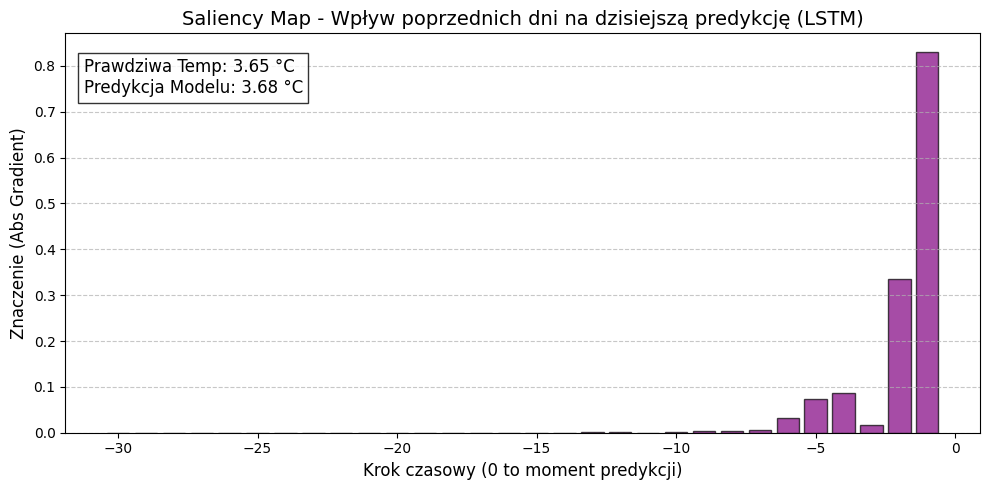

In [39]:
print("\nBadanie interpretowalności modelu (Saliency Map)...")

# Wybieramy jedną sekwencję ze zbioru testowego (np. indeks 100)
sample_idx = 100
X_sample = X_test_t[sample_idx:sample_idx+1].clone() # Kształt: (1, 30, 1)
y_sample_true = y_test_t[sample_idx].item()

# Uruchamiamy śledzenie gradientów dla wejścia (bardzo ważne!)
X_sample.requires_grad = True

# Ustawiamy model w tryb ewaluacji
model_lstm.eval()

# 1. Forward pass (Predykcja)
prediction = model_lstm(X_sample)

# 2. Backward pass (Obliczamy gradienty predykcji względem wejścia X_sample)
model_lstm.zero_grad()
prediction.backward()

# 3. Pobieramy bezwzględne wartości gradientów dla każdego z 30 kroków czasowych
# Im wyższa wartość, tym większy wpływ miał dany dzień na ostateczny wynik.
saliency = X_sample.grad.abs().squeeze().cpu().numpy()

# Odskalowanie predykcji i wartości prawdziwej do Celsjuszy (do celów wyświetlenia)
pred_celsius = scaler.inverse_transform(prediction.detach().cpu().numpy())[0][0]
true_celsius = scaler.inverse_transform([[y_sample_true]])[0][0]

plt.figure(figsize=(10, 5))
time_steps = np.arange(-SEQ_LENGTH, 0) # Oś X: od -30 (najstarsze) do -1 (wczoraj)

# Rysujemy słupki ważności
plt.bar(time_steps, saliency, color='purple', alpha=0.7, edgecolor='black')

plt.title('Saliency Map - Wpływ poprzednich dni na dzisiejszą predykcję (LSTM)', fontsize=14)
plt.xlabel('Krok czasowy (0 to moment predykcji)', fontsize=12)
plt.ylabel('Znaczenie (Abs Gradient)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Dodajemy informacje o predykcji na wykresie
info_text = f"Prawdziwa Temp: {true_celsius:.2f} °C\nPredykcja Modelu: {pred_celsius:.2f} °C"
plt.text(0.02, 0.85, info_text, transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plt.tight_layout()
plt.show()